# Trực quan hoá chi tiết — Acceptance Rate Model

Notebook này **mổ xẻ từng bộ phận** của model bằng biểu đồ, để thấy rõ:

| Phần | Nội dung | Hình |
|---|---|---|
| **1** | Dữ liệu đầu vào — tham số hiệu chỉnh đến từ đâu | `V1` |
| **2** | Cơ chế model — logit hoạt động thế nào | `V2` |
| **3** | Model 1 — theo giá đối thủ (market vs firm) | `V3`, `V4` |
| **4** | Model 2 — theo thời tiết & giờ | `V5` |
| **5** | Độ nhạy — giả định nào ảnh hưởng nhiều nhất | `V6` |
| **6** | Bảng điều khiển tổng hợp | `V7` |

> **Khác 2 notebook trước:** `01` dựng model, `02` trình bày theo mốc giá cho mentor. Notebook này
> tập trung **giải thích trực quan** — mỗi bước một hình.

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
warnings.filterwarnings("ignore")
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK, LIGHT = "#222222", "#CCCCCC"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

P0 = 0.5
def sigmoid(z): return 1 / (1 + np.exp(-z))
def b_tu_eps(eps, P0=P0): return eps / (1 - P0)
def P_accept(ty_le, eps, P0=P0, dich=0.0):
    return sigmoid(np.log(P0/(1-P0)) + b_tu_eps(eps, P0) * (np.log(ty_le) - np.log1p(dich)))

EPS_M = [-0.3, -0.5, -0.7]
EPS_F = [-1.2, -2.0, -3.0]
EPS_CHINH = -2.0
print("Cau hinh xong.")

Cau hinh xong.


---

# PHẦN 1 — Dữ liệu đầu vào

Model có 4 tham số. **Hai trong số đó đo trực tiếp từ dữ liệu**, không phải giả định. Phần này cho
thấy chúng đến từ đâu.

In [2]:
cols = ["target_request_id", "gio_vn", "weather_main", "target_shown_price", "target_shown_multiplier"]
d = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=cols)
d = d.drop_duplicates(subset="target_request_id")
d["mua"] = d.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
print(f"So chuyen: {len(d):,}")

gm = d.groupby("mua").target_shown_multiplier.mean()
DICH_MUA = gm[True] / gm[False] - 1
gh = d.groupby("gio_vn").target_shown_multiplier.mean()
DICH_GIO = gh / gh.mean() - 1
GIA_DT = d.target_shown_price.median()
print(f"DICH_MUA = {DICH_MUA*100:+.2f}%  |  bien do gio = {(gh.max()/gh.min()-1)*100:.1f}%  |  gia median = {GIA_DT:,.0f}")

So chuyen: 1,724,714
DICH_MUA = +4.61%  |  bien do gio = 50.0%  |  gia median = 114,000


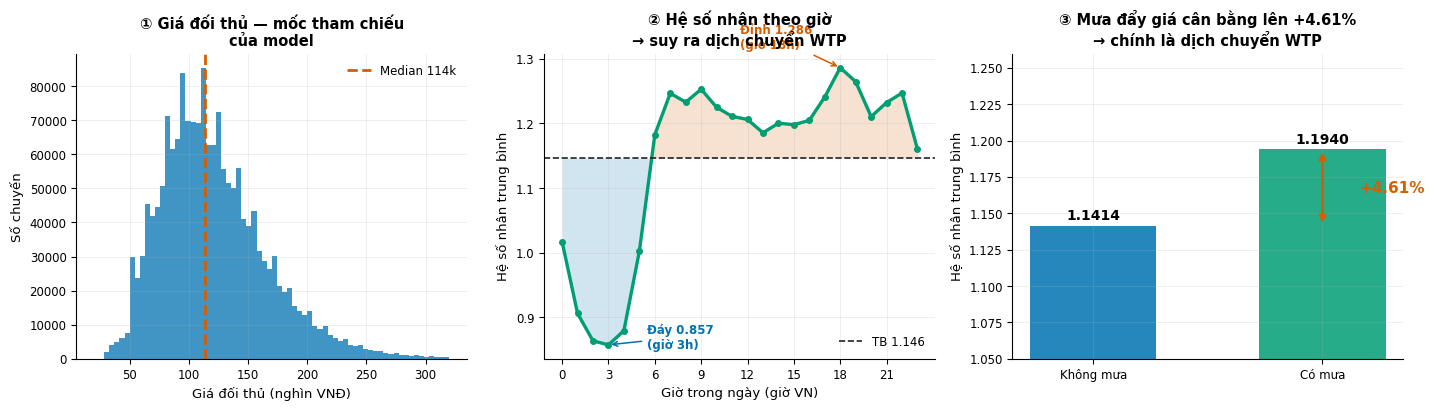

Y tuong: he so nhan quan sat duoc = GIA CAN BANG thi truong.
Mua -> thi truong chap nhan gia cao hon 4.61% => WTP dich chuyen 4.61%.


In [3]:
# ===================== HINH V1 =====================
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))

# --- V1a: phan bo gia doi thu ---
gia = d.target_shown_price / 1000
ax[0].hist(gia, bins=70, range=(20, 320), color=BLUE, alpha=0.75, lw=0)
ax[0].axvline(GIA_DT/1000, color=RED, lw=2, ls="--", label=f"Median {GIA_DT/1000:.0f}k")
ax[0].set_xlabel("Giá đối thủ (nghìn VNĐ)"); ax[0].set_ylabel("Số chuyến")
ax[0].set_title("① Giá đối thủ — mốc tham chiếu\ncủa model", fontweight="bold")
ax[0].legend(frameon=False)

# --- V1b: he so nhan theo gio -> WTP theo gio ---
ax[1].plot(gh.index, gh.values, color=GREEN, lw=2.4, marker="o", ms=4)
ax[1].axhline(gh.mean(), color=INK, lw=1.2, ls="--", label=f"TB {gh.mean():.3f}")
ax[1].fill_between(gh.index, gh.mean(), gh.values, where=(gh.values >= gh.mean()),
                   color=RED, alpha=0.18, lw=0, interpolate=True)
ax[1].fill_between(gh.index, gh.mean(), gh.values, where=(gh.values < gh.mean()),
                   color=BLUE, alpha=0.18, lw=0, interpolate=True)
ax[1].annotate(f"Đỉnh {gh.max():.3f}\n(giờ {gh.idxmax()}h)", xy=(gh.idxmax(), gh.max()),
               xytext=(gh.idxmax()-6.5, gh.max()+0.03), fontsize=8.5, fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.1))
ax[1].annotate(f"Đáy {gh.min():.3f}\n(giờ {gh.idxmin()}h)", xy=(gh.idxmin(), gh.min()),
               xytext=(gh.idxmin()+2.5, gh.min()-0.005), fontsize=8.5, fontweight="bold", color=BLUE,
               arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.1))
ax[1].set_xlabel("Giờ trong ngày (giờ VN)"); ax[1].set_ylabel("Hệ số nhân trung bình")
ax[1].set_title("② Hệ số nhân theo giờ\n→ suy ra dịch chuyển WTP", fontweight="bold")
ax[1].set_xticks(range(0, 24, 3)); ax[1].legend(frameon=False, loc="lower right")

# --- V1c: mua vs khong mua ---
bars = ax[2].bar(["Không mưa", "Có mưa"], [gm[False], gm[True]],
                 color=[BLUE, GREEN], alpha=0.85, width=0.55)
for b_, v in zip(bars, [gm[False], gm[True]]):
    ax[2].text(b_.get_x()+b_.get_width()/2, v+0.004, f"{v:.4f}", ha="center",
               fontsize=10, fontweight="bold")
ax[2].set_ylim(1.05, gm[True]*1.055)
ax[2].set_ylabel("Hệ số nhân trung bình")
ax[2].set_title(f"③ Mưa đẩy giá cân bằng lên {DICH_MUA*100:+.2f}%\n→ chính là dịch chuyển WTP",
                fontweight="bold")
ax[2].annotate("", xy=(1, gm[True]), xytext=(1, gm[False]),
               arrowprops=dict(arrowstyle="<->", color=RED, lw=2))
ax[2].text(1.16, (gm[True]+gm[False])/2, f"{DICH_MUA*100:+.2f}%", color=RED,
           fontsize=11, fontweight="bold", va="center")

plt.tight_layout(); plt.savefig(HINH / "V1_du_lieu_dau_vao.png"); plt.show()
print("Y tuong: he so nhan quan sat duoc = GIA CAN BANG thi truong.")
print("Mua -> thi truong chap nhan gia cao hon 4.61% => WTP dich chuyen 4.61%.")

---

# PHẦN 2 — Cơ chế model hoạt động

Model chỉ là hàm sigmoid. Phần này tách ra xem **từng tham số làm gì**.

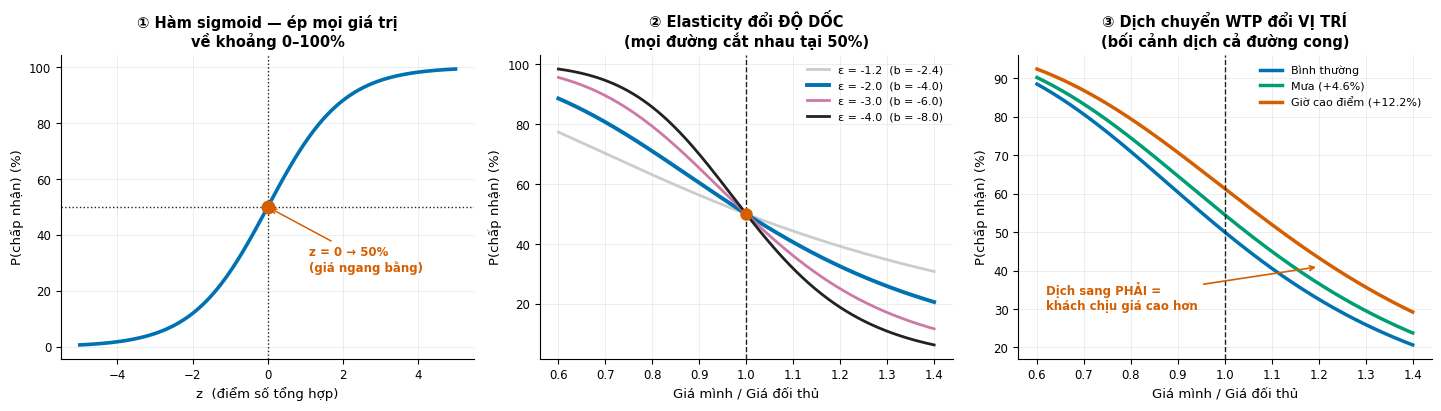

Tom tat: ELASTICITY -> do doc | DICH WTP -> vi tri ngang | P0 -> chieu cao tai diem ngang bang


In [4]:
# ===================== HINH V2 =====================
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))

# --- V2a: sigmoid co ban ---
z = np.linspace(-5, 5, 300)
ax[0].plot(z, sigmoid(z)*100, color=BLUE, lw=2.6)
ax[0].axhline(50, color=INK, lw=1, ls=":"); ax[0].axvline(0, color=INK, lw=1, ls=":")
ax[0].plot(0, 50, "o", color=RED, ms=9, zorder=5)
ax[0].annotate("z = 0 → 50%\n(giá ngang bằng)", xy=(0, 50), xytext=(1.1, 27),
               fontsize=8.5, fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.1))
ax[0].set_xlabel("z  (điểm số tổng hợp)"); ax[0].set_ylabel("P(chấp nhận) (%)")
ax[0].set_title("① Hàm sigmoid — ép mọi giá trị\nvề khoảng 0–100%", fontweight="bold")

# --- V2b: elasticity doi DO DOC ---
r = np.linspace(0.6, 1.4, 300)
for e, col, lw in zip([-1.2, -2.0, -3.0, -4.0], [LIGHT, BLUE, PURPLE, INK], [2, 2.8, 2, 2]):
    ax[1].plot(r, P_accept(r, e)*100, color=col, lw=lw, label=f"ε = {e}  (b = {b_tu_eps(e):.1f})")
ax[1].axvline(1.0, color=INK, lw=1, ls="--"); ax[1].plot(1.0, 50, "o", color=RED, ms=8, zorder=5)
ax[1].set_xlabel("Giá mình / Giá đối thủ"); ax[1].set_ylabel("P(chấp nhận) (%)")
ax[1].set_title("② Elasticity đổi ĐỘ DỐC\n(mọi đường cắt nhau tại 50%)", fontweight="bold")
ax[1].legend(frameon=False, fontsize=8)

# --- V2c: dich WTP doi VI TRI ---
for dd, col, ten in zip([0.0, DICH_MUA, DICH_GIO.max()], [BLUE, GREEN, RED],
                        ["Bình thường", f"Mưa ({DICH_MUA*100:+.1f}%)",
                         f"Giờ cao điểm ({DICH_GIO.max()*100:+.1f}%)"]):
    ax[2].plot(r, P_accept(r, EPS_CHINH, dich=dd)*100, color=col, lw=2.5, label=ten)
ax[2].axvline(1.0, color=INK, lw=1, ls="--")
ax[2].annotate("Dịch sang PHẢI =\nkhách chịu giá cao hơn", xy=(1.20, 41), xytext=(0.62, 30),
               fontsize=8.5, fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
ax[2].set_xlabel("Giá mình / Giá đối thủ"); ax[2].set_ylabel("P(chấp nhận) (%)")
ax[2].set_title("③ Dịch chuyển WTP đổi VỊ TRÍ\n(bối cảnh dịch cả đường cong)", fontweight="bold")
ax[2].legend(frameon=False, fontsize=8, loc="upper right")

plt.tight_layout(); plt.savefig(HINH / "V2_co_che_model.png"); plt.show()
print("Tom tat: ELASTICITY -> do doc | DICH WTP -> vi tri ngang | P0 -> chieu cao tai diem ngang bang")

---

# PHẦN 3 — Model 1: theo giá đối thủ

Phải tách **2 tình huống** vì chúng cho kết luận **ngược nhau**.

## 3A. Cả thị trường cùng tăng giá (market-level)

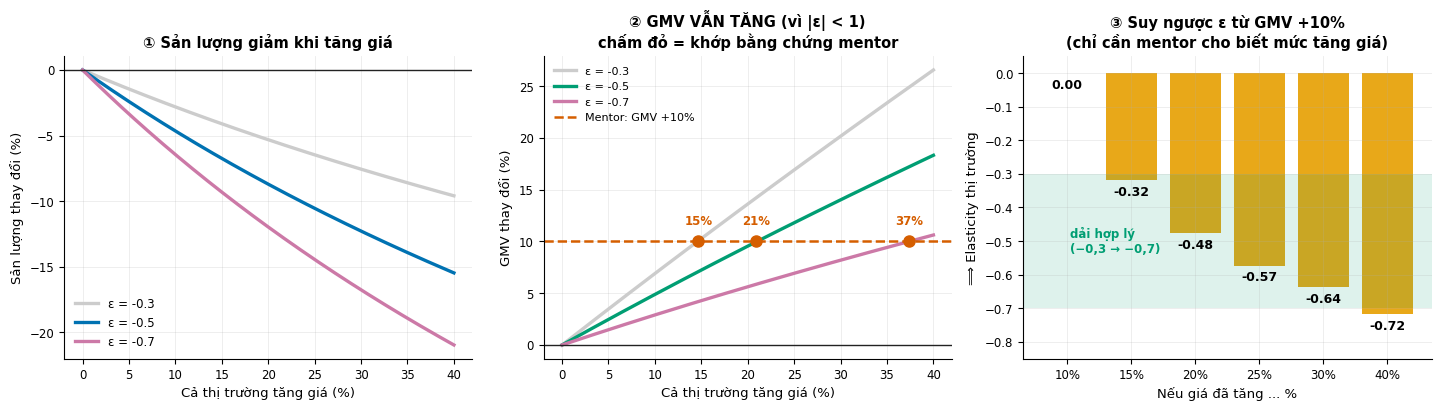

In [5]:
# ===================== HINH V3 =====================
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
p_grid = np.linspace(0, 0.40, 200)

# --- V3a: san luong giam ---
for e, col in zip(EPS_M, [LIGHT, BLUE, PURPLE]):
    ax[0].plot(p_grid*100, ((1+p_grid)**e - 1)*100, color=col, lw=2.4, label=f"ε = {e}")
ax[0].axhline(0, color=INK, lw=1)
ax[0].set_xlabel("Cả thị trường tăng giá (%)"); ax[0].set_ylabel("Sản lượng thay đổi (%)")
ax[0].set_title("① Sản lượng giảm khi tăng giá", fontweight="bold")
ax[0].legend(frameon=False)

# --- V3b: GMV van tang ---
for e, col in zip(EPS_M, [LIGHT, GREEN, PURPLE]):
    ax[1].plot(p_grid*100, ((1+p_grid)**(1+e) - 1)*100, color=col, lw=2.4, label=f"ε = {e}")
ax[1].axhline(10, color=RED, lw=1.8, ls="--", label="Mentor: GMV +10%")
ax[1].axhline(0, color=INK, lw=1)
# danh dau giao diem voi +10%
for e, col in zip(EPS_M, [MUT, GREEN, PURPLE]):
    yy = ((1+p_grid)**(1+e) - 1)*100
    if yy.max() >= 10:
        i = int(np.argmin(abs(yy - 10)))
        ax[1].plot(p_grid[i]*100, 10, "o", color=RED, ms=8, zorder=6)
        ax[1].text(p_grid[i]*100, 11.6, f"{p_grid[i]*100:.0f}%", ha="center",
                   fontsize=8.5, fontweight="bold", color=RED)
ax[1].set_xlabel("Cả thị trường tăng giá (%)"); ax[1].set_ylabel("GMV thay đổi (%)")
ax[1].set_title("② GMV VẪN TĂNG (vì |ε| < 1)\nchấm đỏ = khớp bằng chứng mentor", fontweight="bold")
ax[1].legend(frameon=False, fontsize=8)

# --- V3c: suy nguoc elasticity ---
p_moc = np.array([0.10, 0.15, 0.20, 0.25, 0.30, 0.40])
eps_ngu_y = np.log(1.10/(1+p_moc)) / np.log(1+p_moc)
b_ = ax[2].bar([f"{p*100:.0f}%" for p in p_moc], eps_ngu_y, color=ORANGE, alpha=0.9)
for bb, v in zip(b_, eps_ngu_y):
    ax[2].text(bb.get_x()+bb.get_width()/2, v-0.045, f"{v:.2f}", ha="center",
               fontsize=9, fontweight="bold")
ax[2].axhspan(-0.7, -0.3, color=GREEN, alpha=0.13, lw=0)
ax[2].text(0.05, -0.5, "dải hợp lý\n(−0,3 → −0,7)", fontsize=8.5, color=GREEN,
           fontweight="bold", va="center")
ax[2].set_xlabel("Nếu giá đã tăng ... %"); ax[2].set_ylabel("⟹ Elasticity thị trường")
ax[2].set_title("③ Suy ngược ε từ GMV +10%\n(chỉ cần mentor cho biết mức tăng giá)", fontweight="bold")
ax[2].set_ylim(-0.85, 0.05)

plt.tight_layout(); plt.savefig(HINH / "V3_model1_market.png"); plt.show()

## 3B. Chỉ mình tăng giá — đối thủ giữ nguyên (firm-level)

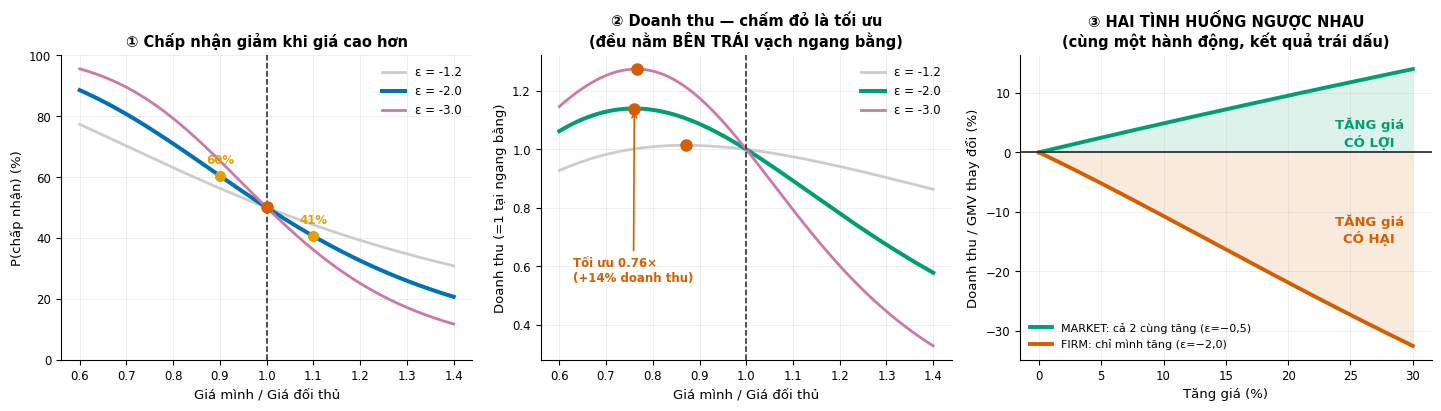

Panel 3 la ket luan quan trong nhat: 'ca thi truong tang gia' va 'rieng minh tang gia'
la HAI CAU HOI KHAC NHAU, cho ket qua TRAI DAU. Khong mau thuan.


In [6]:
# ===================== HINH V4 =====================
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
r = np.linspace(0.6, 1.4, 300)

# --- V4a: duong cong chap nhan ---
for e, col, lw in zip(EPS_F, [LIGHT, BLUE, PURPLE], [2, 2.9, 2]):
    ax[0].plot(r, P_accept(r, e)*100, color=col, lw=lw, label=f"ε = {e}")
ax[0].axvline(1.0, color=INK, lw=1.1, ls="--")
ax[0].plot(1.0, 50, "o", color=RED, ms=8, zorder=6)
for p_ in [0.9, 1.1]:
    v = P_accept(p_, EPS_CHINH)*100
    ax[0].plot(p_, v, "o", color=ORANGE, ms=7, zorder=6)
    ax[0].text(p_, v+4, f"{v:.0f}%", ha="center", fontsize=8.5, fontweight="bold", color=ORANGE)
ax[0].set_xlabel("Giá mình / Giá đối thủ"); ax[0].set_ylabel("P(chấp nhận) (%)")
ax[0].set_title("① Chấp nhận giảm khi giá cao hơn", fontweight="bold")
ax[0].legend(frameon=False); ax[0].set_ylim(0, 100)

# --- V4b: doanh thu + diem toi uu ---
for e, col, lw in zip(EPS_F, [LIGHT, GREEN, PURPLE], [2, 2.9, 2]):
    R = r * P_accept(r, e); R = R / (1.0 * P_accept(1.0, e))
    ax[1].plot(r, R, color=col, lw=lw, label=f"ε = {e}")
    i = int(np.argmax(R))
    ax[1].plot(r[i], R[i], "o", color=RED, ms=8, zorder=6)
ax[1].axvline(1.0, color=INK, lw=1.1, ls="--")
R2 = r * P_accept(r, EPS_CHINH); R2 = R2 / (1.0 * P_accept(1.0, EPS_CHINH))
i2 = int(np.argmax(R2))
ax[1].annotate(f"Tối ưu {r[i2]:.2f}×\n(+{(R2[i2]-1)*100:.0f}% doanh thu)",
               xy=(r[i2], R2[i2]), xytext=(0.63, 0.55),
               fontsize=8.5, fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
ax[1].set_xlabel("Giá mình / Giá đối thủ"); ax[1].set_ylabel("Doanh thu (=1 tại ngang bằng)")
ax[1].set_title("② Doanh thu — chấm đỏ là tối ưu\n(đều nằm BÊN TRÁI vạch ngang bằng)", fontweight="bold")
ax[1].legend(frameon=False)

# --- V4c: so sanh MARKET vs FIRM ---
p2 = np.linspace(0, 0.30, 200)
y_m = ((1+p2)**(1+(-0.5)) - 1)*100
y_f = np.array([( (1+p)*P_accept(1+p, EPS_CHINH)/(1.0*P_accept(1.0,EPS_CHINH)) - 1)*100 for p in p2])
ax[2].plot(p2*100, y_m, color=GREEN, lw=2.8, label="MARKET: cả 2 cùng tăng (ε=−0,5)")
ax[2].plot(p2*100, y_f, color=RED,   lw=2.8, label="FIRM: chỉ mình tăng (ε=−2,0)")
ax[2].fill_between(p2*100, 0, y_m, color=GREEN, alpha=0.13, lw=0)
ax[2].fill_between(p2*100, 0, y_f, color=RED,   alpha=0.13, lw=0)
ax[2].axhline(0, color=INK, lw=1.2)
ax[2].text(26.5, 3.2, "TĂNG giá\nCÓ LỢI", color=GREEN, fontsize=9.5, fontweight="bold", ha="center", va="center")
ax[2].text(26.5, -13, "TĂNG giá\nCÓ HẠI", color=RED, fontsize=9.5, fontweight="bold", ha="center", va="center")
ax[2].set_xlabel("Tăng giá (%)"); ax[2].set_ylabel("Doanh thu / GMV thay đổi (%)")
ax[2].set_title("③ HAI TÌNH HUỐNG NGƯỢC NHAU\n(cùng một hành động, kết quả trái dấu)",
                fontweight="bold")
ax[2].legend(frameon=False, fontsize=8, loc="lower left")

plt.tight_layout(); plt.savefig(HINH / "V4_model1_firm.png"); plt.show()
print("Panel 3 la ket luan quan trong nhat: 'ca thi truong tang gia' va 'rieng minh tang gia'")
print("la HAI CAU HOI KHAC NHAU, cho ket qua TRAI DAU. Khong mau thuan.")

---

# PHẦN 4 — Model 2: theo thời tiết & giờ

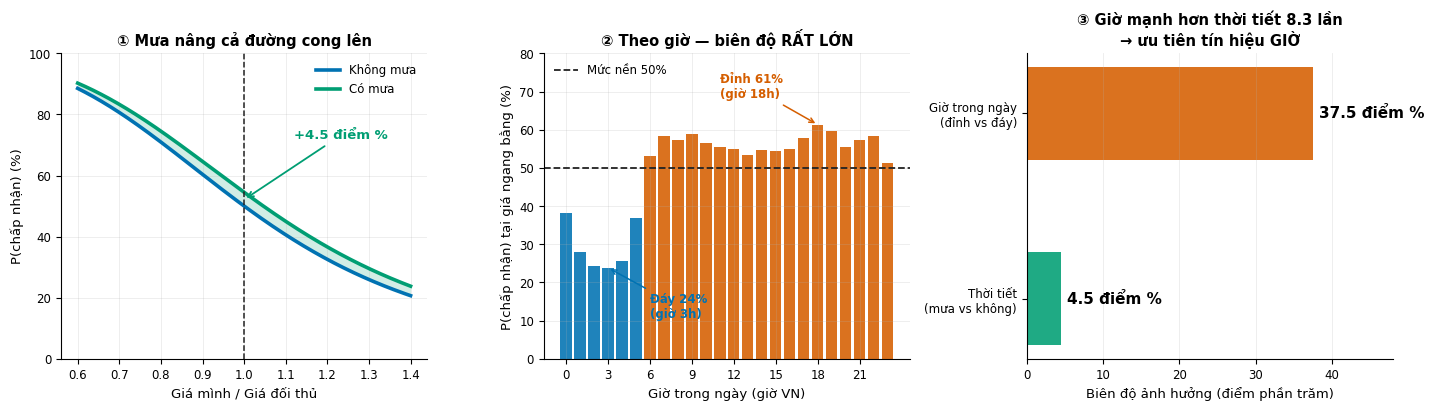

Bien do mua: 4.49 diem % | bien do gio: 37.48 diem % -> gap 8.3 lan


In [7]:
# ===================== HINH V5 =====================
def khung(h):
    if h < 5:  return 0
    if h < 7:  return 1
    if h < 9:  return 2
    if h < 16: return 3
    if h < 19: return 4
    return 5
TEN = ["Đêm khuya\n(0-5h)", "Sáng sớm\n(5-7h)", "Cao điểm sáng\n(7-9h)",
       "Giữa ngày\n(9-16h)", "Cao điểm chiều\n(16-19h)", "Tối\n(19-24h)"]
dich_khung = [np.mean([DICH_GIO[h] for h in range(24) if khung(h) == k]) for k in range(6)]

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))

# --- V5a: mua vs khong mua ---
Pk = P_accept(r, EPS_CHINH, dich=0.0)*100
Pm = P_accept(r, EPS_CHINH, dich=DICH_MUA)*100
ax[0].plot(r, Pk, color=BLUE,  lw=2.6, label="Không mưa")
ax[0].plot(r, Pm, color=GREEN, lw=2.6, label="Có mưa")
ax[0].fill_between(r, Pk, Pm, color=GREEN, alpha=0.18, lw=0)
ax[0].axvline(1.0, color=INK, lw=1.1, ls="--")
i0 = int(np.argmin(abs(r-1.0)))
ax[0].annotate(f"+{Pm[i0]-Pk[i0]:.1f} điểm %", xy=(1.0, (Pk[i0]+Pm[i0])/2),
               xytext=(1.12, 72), fontsize=9.5, fontweight="bold", color=GREEN,
               arrowprops=dict(arrowstyle="->", color=GREEN, lw=1.3))
ax[0].set_xlabel("Giá mình / Giá đối thủ"); ax[0].set_ylabel("P(chấp nhận) (%)")
ax[0].set_title("① Mưa nâng cả đường cong lên", fontweight="bold")
ax[0].legend(frameon=False); ax[0].set_ylim(0, 100)

# --- V5b: theo 24 gio ---
Pg = np.array([P_accept(1.0, EPS_CHINH, dich=DICH_GIO[h])*100 for h in range(24)])
ax[1].bar(range(24), Pg, color=[RED if v > 50 else BLUE for v in Pg], alpha=0.88)
ax[1].axhline(50, color=INK, lw=1.3, ls="--", label="Mức nền 50%")
ax[1].annotate(f"Đỉnh {Pg.max():.0f}%\n(giờ {Pg.argmax()}h)", xy=(Pg.argmax(), Pg.max()),
               xytext=(Pg.argmax()-7, Pg.max()+7), fontsize=8.5, fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.1))
ax[1].annotate(f"Đáy {Pg.min():.0f}%\n(giờ {Pg.argmin()}h)", xy=(Pg.argmin(), Pg.min()),
               xytext=(Pg.argmin()+3, Pg.min()-13), fontsize=8.5, fontweight="bold", color=BLUE,
               arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.1))
ax[1].set_xlabel("Giờ trong ngày (giờ VN)"); ax[1].set_ylabel("P(chấp nhận) tại giá ngang bằng (%)")
ax[1].set_title("② Theo giờ — biên độ RẤT LỚN", fontweight="bold")
ax[1].set_xticks(range(0, 24, 3)); ax[1].legend(frameon=False); ax[1].set_ylim(0, 80)

# --- V5c: so sanh do lon GIO vs MUA ---
bd_gio = Pg.max() - Pg.min()
bd_mua = Pm[i0] - Pk[i0]
bb = ax[2].barh(["Thời tiết\n(mưa vs không)", "Giờ trong ngày\n(đỉnh vs đáy)"],
                [bd_mua, bd_gio], color=[GREEN, RED], alpha=0.88, height=0.5)
for b_, v in zip(bb, [bd_mua, bd_gio]):
    ax[2].text(v+0.8, b_.get_y()+b_.get_height()/2, f"{v:.1f} điểm %",
               va="center", fontsize=11, fontweight="bold")
ax[2].set_xlabel("Biên độ ảnh hưởng (điểm phần trăm)")
ax[2].set_title(f"③ Giờ mạnh hơn thời tiết {bd_gio/bd_mua:.1f} lần\n→ ưu tiên tín hiệu GIỜ",
                fontweight="bold")
ax[2].set_xlim(0, bd_gio*1.28); ax[2].grid(axis="y", alpha=0)

plt.tight_layout(); plt.savefig(HINH / "V5_model2_thoitiet_gio.png"); plt.show()
print(f"Bien do mua: {bd_mua:.2f} diem % | bien do gio: {bd_gio:.2f} diem % -> gap {bd_gio/bd_mua:.1f} lan")

---

# PHẦN 5 — Độ nhạy: giả định nào ảnh hưởng nhiều nhất?

Model có 2 tham số giả định (`ε`, `P₀`) và 2 tham số đo từ dữ liệu. Phần này định lượng xem
**thay đổi từng cái thì kết quả lệch bao nhiêu**.

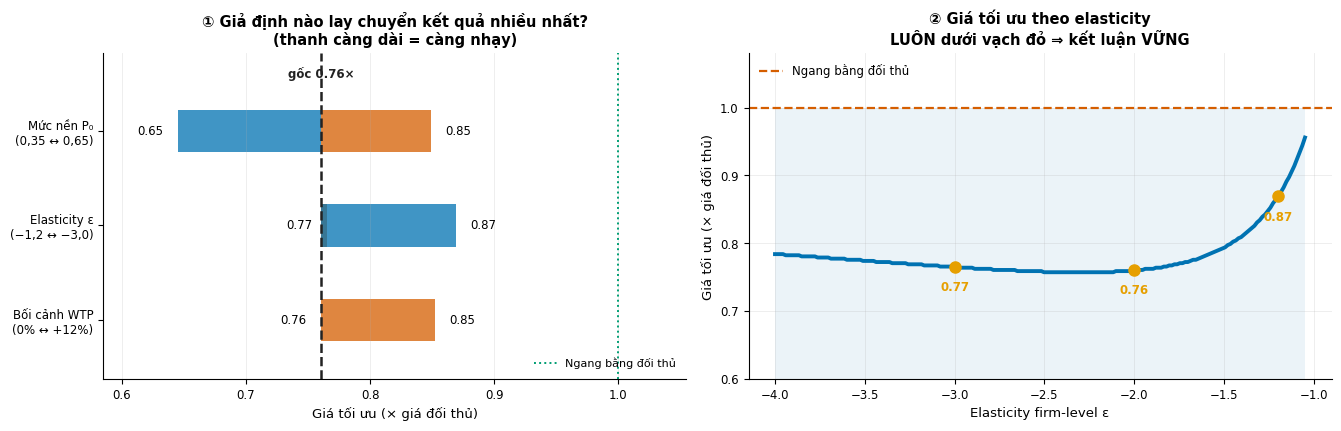

Ket luan:
  - P0 (muc chap nhan nen) lay chuyen ket qua MANH HON elasticity
  - Nhung du doi bat ky gia dinh nao trong dai hop ly, gia toi uu VAN duoi 1.0x
  - => ket luan CHIEU (nen giam gia) vung; con con so TUYET DOI thi khong


In [8]:
# ===================== HINH V6 =====================
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.4))

# --- V6a: tornado - anh huong tung gia dinh len GIA TOI UU ---
def gia_toi_uu(eps=EPS_CHINH, P0_=P0, dich=0.0):
    rr = np.linspace(0.5, 1.5, 600)
    R = rr * P_accept(rr, eps, P0_, dich)
    return rr[int(np.argmax(R))]

goc = gia_toi_uu()
bien = [
    ("Elasticity ε\n(−1,2 ↔ −3,0)",  gia_toi_uu(eps=-1.2),           gia_toi_uu(eps=-3.0)),
    ("Mức nền P₀\n(0,35 ↔ 0,65)",     gia_toi_uu(P0_=0.35),           gia_toi_uu(P0_=0.65)),
    ("Bối cảnh WTP\n(0% ↔ +12%)",     gia_toi_uu(dich=0.0),           gia_toi_uu(dich=0.122)),
]
bien = sorted(bien, key=lambda t: abs(t[2]-t[1]))
y = np.arange(len(bien))
for i, (ten, lo, hi) in enumerate(bien):
    ax[0].barh(i, hi-goc, left=goc, color=RED,  alpha=0.75, height=0.45)
    ax[0].barh(i, lo-goc, left=goc, color=BLUE, alpha=0.75, height=0.45)
    ax[0].text(min(lo, hi)-0.012, i, f"{min(lo,hi):.2f}", ha="right", va="center", fontsize=8.5)
    ax[0].text(max(lo, hi)+0.012, i, f"{max(lo,hi):.2f}", ha="left", va="center", fontsize=8.5)
ax[0].axvline(goc, color=INK, lw=1.8, ls="--")
ax[0].set_xlim(0.585, 1.055); ax[0].set_ylim(-0.62, 2.82)
ax[0].text(goc, 2.56, f"gốc {goc:.2f}×", ha="center", fontsize=8.5,
           fontweight="bold", color=INK)
ax[0].set_yticks(y); ax[0].set_yticklabels([b[0] for b in bien], fontsize=8.5)
ax[0].set_xlabel("Giá tối ưu (× giá đối thủ)")
ax[0].set_title("① Giả định nào lay chuyển kết quả nhiều nhất?\n(thanh càng dài = càng nhạy)",
                fontweight="bold")
ax[0].grid(axis="y", alpha=0)
ax[0].axvline(1.0, color=GREEN, lw=1.4, ls=":", label="Ngang bằng đối thủ")
ax[0].legend(frameon=False, loc="lower right", fontsize=8)

# --- V6b: gia toi uu theo elasticity, lien tuc ---
eps_g = np.linspace(-4.0, -1.05, 200)
opt = [gia_toi_uu(eps=e) for e in eps_g]
ax[1].plot(eps_g, opt, color=BLUE, lw=2.8)
ax[1].axhline(1.0, color=RED, lw=1.6, ls="--", label="Ngang bằng đối thủ")
ax[1].fill_between(eps_g, 0.6, 1.0, color=BLUE, alpha=0.08, lw=0)
for e in EPS_F:
    ax[1].plot(e, gia_toi_uu(eps=e), "o", color=ORANGE, ms=8, zorder=6)
    ax[1].text(e, gia_toi_uu(eps=e)-0.035, f"{gia_toi_uu(eps=e):.2f}", ha="center",
               fontsize=8.5, fontweight="bold", color=ORANGE)
ax[1].set_xlabel("Elasticity firm-level ε"); ax[1].set_ylabel("Giá tối ưu (× giá đối thủ)")
ax[1].set_title("② Giá tối ưu theo elasticity\nLUÔN dưới vạch đỏ ⇒ kết luận VỮNG", fontweight="bold")
ax[1].legend(frameon=False, loc="upper left"); ax[1].set_ylim(0.6, 1.08)

plt.tight_layout(); plt.savefig(HINH / "V6_do_nhay.png"); plt.show()
print("Ket luan:")
print("  - P0 (muc chap nhan nen) lay chuyen ket qua MANH HON elasticity")
print("  - Nhung du doi bat ky gia dinh nao trong dai hop ly, gia toi uu VAN duoi 1.0x")
print("  - => ket luan CHIEU (nen giam gia) vung; con con so TUYET DOI thi khong")

---

# PHẦN 6 — Bảng điều khiển tổng hợp

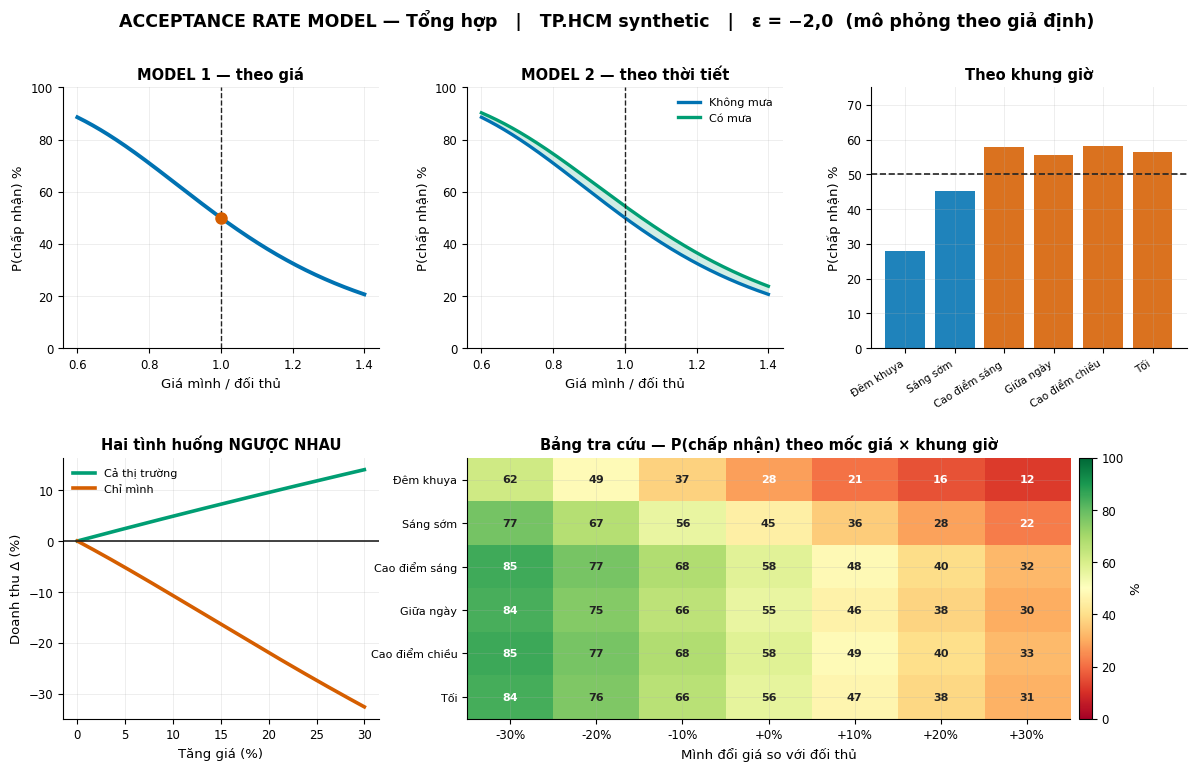

In [9]:
# ===================== HINH V7 =====================
fig = plt.figure(figsize=(14.5, 8.2))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.28)

# (1) duong cong chinh
a1 = fig.add_subplot(gs[0, 0])
a1.plot(r, P_accept(r, EPS_CHINH)*100, color=BLUE, lw=2.8)
a1.axvline(1.0, color=INK, lw=1, ls="--"); a1.plot(1.0, 50, "o", color=RED, ms=8)
a1.set_xlabel("Giá mình / đối thủ"); a1.set_ylabel("P(chấp nhận) %")
a1.set_title("MODEL 1 — theo giá", fontweight="bold"); a1.set_ylim(0, 100)

# (2) mua
a2 = fig.add_subplot(gs[0, 1])
a2.plot(r, Pk, color=BLUE, lw=2.4, label="Không mưa")
a2.plot(r, Pm, color=GREEN, lw=2.4, label="Có mưa")
a2.fill_between(r, Pk, Pm, color=GREEN, alpha=0.18, lw=0)
a2.axvline(1.0, color=INK, lw=1, ls="--")
a2.set_xlabel("Giá mình / đối thủ"); a2.set_ylabel("P(chấp nhận) %")
a2.set_title("MODEL 2 — theo thời tiết", fontweight="bold")
a2.legend(frameon=False, fontsize=8); a2.set_ylim(0, 100)

# (3) khung gio
a3 = fig.add_subplot(gs[0, 2])
Pkh = [P_accept(1.0, EPS_CHINH, dich=dd)*100 for dd in dich_khung]
a3.bar(range(6), Pkh, color=[RED if v > 50 else BLUE for v in Pkh], alpha=0.88)
a3.axhline(50, color=INK, lw=1.2, ls="--")
a3.set_xticks(range(6)); a3.set_xticklabels([t.split("\n")[0] for t in TEN], rotation=32,
                                            ha="right", fontsize=7.5)
a3.set_ylabel("P(chấp nhận) %")
a3.set_title("Theo khung giờ", fontweight="bold"); a3.set_ylim(0, 75)

# (4) market vs firm
a4 = fig.add_subplot(gs[1, 0])
a4.plot(p2*100, y_m, color=GREEN, lw=2.6, label="Cả thị trường")
a4.plot(p2*100, y_f, color=RED, lw=2.6, label="Chỉ mình")
a4.axhline(0, color=INK, lw=1.2)
a4.set_xlabel("Tăng giá (%)"); a4.set_ylabel("Doanh thu Δ (%)")
a4.set_title("Hai tình huống NGƯỢC NHAU", fontweight="bold")
a4.legend(frameon=False, fontsize=8)

# (5) heatmap
a5 = fig.add_subplot(gs[1, 1:])
moc_ve = [-0.30, -0.20, -0.10, 0.0, 0.10, 0.20, 0.30]
M = np.array([[P_accept(1+p, EPS_CHINH, dich=dd)*100 for p in moc_ve] for dd in dich_khung])
im = a5.imshow(M, cmap="RdYlGn", aspect="auto", vmin=0, vmax=100)
a5.set_xticks(range(len(moc_ve))); a5.set_xticklabels([f"{p*100:+.0f}%" for p in moc_ve])
a5.set_yticks(range(6)); a5.set_yticklabels([t.split("\n")[0] for t in TEN], fontsize=8)
for i in range(6):
    for j in range(len(moc_ve)):
        a5.text(j, i, f"{M[i,j]:.0f}", ha="center", va="center", fontsize=8,
                color="white" if (M[i,j] < 28 or M[i,j] > 78) else INK, fontweight="bold")
a5.set_xlabel("Mình đổi giá so với đối thủ")
a5.set_title("Bảng tra cứu — P(chấp nhận) theo mốc giá × khung giờ", fontweight="bold")
plt.colorbar(im, ax=a5, pad=0.012, label="%")

fig.suptitle("ACCEPTANCE RATE MODEL — Tổng hợp   |   TP.HCM synthetic   |   ε = −2,0  (mô phỏng theo giả định)",
             fontsize=12.5, fontweight="bold", y=0.975)
plt.savefig(HINH / "V7_tong_hop.png", bbox_inches="tight"); plt.show()

---

# Tổng kết

| Hình | Nội dung | Điểm chính |
|---|---|---|
| `V1` | Dữ liệu đầu vào | WTP mưa **+4,61%**, biên độ giờ **50,0%** — đo từ dữ liệu, không giả định |
| `V2` | Cơ chế model | ε đổi **độ dốc**, dịch WTP đổi **vị trí**, P₀ đổi **chiều cao** |
| `V3` | Model 1 market | GMV tăng dù mất khách vì \|ε\| < 1; suy ngược được ε từ GMV +10% |
| `V4` | Model 1 firm | Giá tối ưu **thấp hơn** đối thủ; panel ③ là kết luận quan trọng nhất |
| `V5` | Model 2 | Mưa +4,5 điểm %; **giờ mạnh hơn ~8 lần** |
| `V6` | Độ nhạy | **`P₀` nhạy hơn cả elasticity**, nhưng kết luận **vẫn vững** trên toàn dải |
| `V7` | Tổng hợp | Một hình cho toàn bộ |

## Ba kết luận vững trên mọi giả định

1. Giá tối ưu **thấp hơn** giá đối thủ (cạnh tranh trực tiếp rất co giãn)
2. Mưa **làm tăng** khả năng chấp nhận (~4,5 điểm %)
3. **Giờ** tác động mạnh hơn **thời tiết** khoảng 8 lần

## ⚠️ Nhắc lại giới hạn

Toàn bộ là **mô phỏng dưới giả định elasticity** — dữ liệu không có nhãn accept/reject. Các con số
tuyệt đối (50%, 76%...) phụ thuộc giả định `P₀ = 0,5`. **Chiều và độ lớn tương đối** mới là phần đáng
tin, và đó cũng đúng là thứ mentor yêu cầu (*"tăng hay giảm"*).